In [15]:
from PIL import Image
from IPython.display import display

#resources:
#http://warp.povusers.org/EfficientLZW/part2.html
#https://giflib.sourceforge.net/whatsinagif/index.html
#https://github.com/qalle2/pygif
#https://bitbanksoftware.blogspot.com/2020/07/a-low-memory-gif-decoder.html



In [22]:
class treeNode():
    def __init__(self):
        self.index = None
        self.byte = None
        self.left = None
        self.right = None
        
    def getList(self,code):
        currentNode = self
        outList = [self.byte]
        while True:
            if currentNode == None:
                return outList
            if currentNode.index == code:
                outList.append(currentNode.byte) 
                return outList
            if code < currentNode.index:
                outList.append(currentNode.byte) 
                currentNode = currentNode.left 
            else:
                outList.append(currentNode.byte) 
                currentNode = currentNode.right
                
    def append(self,code,byte):
        currentNode = self        
        while True:
            if currentNode.index == code:
                return False
            elif currentNode.index == None:
                currentNode.index = code
                if currentNode.byte == None:
                    currentNode.byte = byte
                    return True
            elif code < currentNode.index:
                if currentNode.left == None:
                    currentNode.left = treeNode()
                currentNode = currentNode.left 
            else:
                if currentNode.right == None:
                    currentNode.right = treeNode()
                currentNode = currentNode.right
                    
def ByteArrayReverse(Barr):
    l = list(Barr)
    l = l[::-1]
    return bytearray(l)
    
def get_CodeValue(Code,treeNode,ColorTableLen):
    if Code < ColorTableLen:
        return Code.to_bytes(1)
    else:
        newCode = Code
        outList = treeNode.getList(Code)
        outList = outList[::-1]
        return bytearray(outList)
        
#def get_CodeValue(Code,codeTable,ColorTableLen):
    #if Code < ColorTableLen:
        #return Code.to_bytes(1)
    #else:
        #tup = codeTable[Code-(ColorTableLen+2)]
        #output = get_CodeValue(tup[0],codeTable,ColorTableLen) + tup[1]
        #print(output)
        #return output
def lzw_Decompress(src,LZW_Min_Code):
    ColorTableLen = 2**LZW_Min_Code
    print('ColorTableLen:',ColorTableLen)
    print('LZW_Min_Code:',LZW_Min_Code)
    ClearCode = ColorTableLen
    ImgEndCode = ColorTableLen + 1
    CodeLen = LZW_Min_Code+1
    lastCode = 0
    K = 0
    Code = None
    Codekey = None
    indexStream = bytearray()
    datablock = bytearray(256)
    datablockIndex = 0
    codeTree = treeNode()
    byte = 0
    BitIndex = 0
    newTableIndex = ImgEndCode + 1
    ByteCount = 0
    BlockN = 0
    FirstCodeFlag = False
    ZeroBlockLenFlag = False
    while True:       
        Code = bytearray(CodeLen//8+1)
        #print('bc:',ByteCount,' ',end='')
        #print('['+str(newTableIndex)+']',end="")
        #print('('+str(CodeLen)+')',end="")
        #print('|'+str(BitIndex)+'|',end="")
        for i in range(CodeLen):   
            if ByteCount == 0:
                ByteCount = src.read(1)[0]
                datablock = src.read(ByteCount)
                datablockIndex = 0
                #print("BlockN: ",BlockN,"BlockLen: ",ByteCount)
                if ByteCount == 0:
                    ZeroBlockLenFlag = True
                    break
                BlockN += 1
                            
            if BitIndex == 0:
                byte = datablock[datablockIndex]
                datablockIndex += 1
                ByteCount -= 1

            bit = (byte >> BitIndex) & 1
            #print(bit,end="")
            if bit:
                Code[i//8] = Code[i//8] | 1<<i%8
            BitIndex += 1
            if BitIndex == 8:
                BitIndex = 0
        if ZeroBlockLenFlag:
            break
        #print(' ',end="")
        #binary_string = ''.join(f'{b:08b}' for b in bytearray([Code[-1]]))
        #print(binary_string,' ',end="")
        #binary_string = ''.join(f'{b:08b}' for b in bytearray([Code[0]]))
        #print(binary_string,' ',end="")
        
        CodeKey = int.from_bytes(Code,'little')
        #print(' ',end="")
        #print(CodeKey,end="")
        #print(' -> ',end="")
        #print('')
        if CodeKey == ClearCode:
            #print('Clear Code - Initializing codeTable')
            codeTree = treeNode()
            newTableIndex = ImgEndCode+1
            FirstCodeFlag = False
            CodeLen = LZW_Min_Code+1         
        elif CodeKey == ImgEndCode:
            #print('Image End Code - Decoding Complete')
            break
        else:
            if not FirstCodeFlag:
                #print('First Code - Appending to indexStream')
                indexStream += bytearray(get_CodeValue(CodeKey,codeTree,ColorTableLen))
                FirstCodeFlag = True
            else:
                if (CodeKey < newTableIndex):
                    codearr = get_CodeValue(CodeKey,codeTree,ColorTableLen)
                    indexStream += bytearray(codearr)
                    K = codearr[0]
                    #print('Found adding to stream -',bytearray(codearr))
                else:
                    lastcodearr = get_CodeValue(lastCode,codeTree,ColorTableLen)
                    K = lastcodearr[0]
                    K_arr = bytearray([K])
                    indexStream += bytearray(lastcodearr) + K_arr
                    #print('Not Found adding to stream-',bytearray(lastcodearr) + K_arr)

                #codeTable[newTableIndex] = bytearray(get_CodeValue(lastCode,codeTable,ColorTableLen)) + bytearray([K])
                #codeTable.append((lastCode, bytearray([K])))
                #codeTable.append( (lastCode,K) )
                codeTree.append(lastCode,K)
                if newTableIndex >= 2**CodeLen-1:
                    #print('TableIndex maxed out! ',newTableIndex)
                    #print('Increased to: ',2**(CodeLen+1)-1)
                    if CodeLen < 12:
                        CodeLen += 1
                    
                newTableIndex += 1
        lastCode = CodeKey
    return indexStream

def blit(arr,callback,startPos,frameSize,ColorTable):
    scr_y = startPos[1]
    count = 0
    for i,byte in enumerate(arr):
        scr_x = i%frameSize[0] + startPos[0]
        if scr_x == startPos[0] and i != 0:
             scr_y+= 1
        callback(scr_x,scr_y,ColorTable[byte])


def TestImage(ImagePath,ColorTablePath,frameSize,min_code):
    ColorTable = []
    newColorTable = []
    
    with open(ColorTablePath, 'r') as file:
        ColorTable = [tuple(line.strip().replace('(','').replace(')','').split(", ")) for line in file.readlines()]
        
    for color in ColorTable:
        tup = (int(color[0]),int(color[1]),int(color[2]))
        newColorTable.append(tup)
    ColorTable = newColorTable
    
    src = open(ImagePath, "rb")
    
    decompressed = lzw_Decompress(src,min_code)
    src.close()
    # Create a blank white RGB image
    img = Image.new('RGB', frameSize, color='white')
    def setPixel(x,y,color):
        px = img.load()
        try:
            px[x,y] = color
        except Exception as e:
            print(x,y)
            print(e)
    blit(decompressed,setPixel,(0,0),frameSize,ColorTable)
    display(img)

In [23]:
TestImage('jake(240x240).bin','jake(240x240)-ColorTable.txt',(240,240),8)

ColorTableLen: 256
LZW_Min_Code: 8
0 240
image index out of range
1 240
image index out of range
2 240
image index out of range
3 240
image index out of range
4 240
image index out of range
5 240
image index out of range
6 240
image index out of range
7 240
image index out of range
8 240
image index out of range
9 240
image index out of range
10 240
image index out of range
11 240
image index out of range
12 240
image index out of range
13 240
image index out of range
14 240
image index out of range
15 240
image index out of range
16 240
image index out of range
17 240
image index out of range
18 240
image index out of range
19 240
image index out of range
20 240
image index out of range
21 240
image index out of range
22 240
image index out of range
23 240
image index out of range
24 240
image index out of range
25 240
image index out of range
26 240
image index out of range
27 240
image index out of range
28 240
image index out of range
29 240
image index out of range
30 240
image in

KeyboardInterrupt: 

ColorTableLen: 64
LZW_Min_Code: 6
CodeTable len:  697


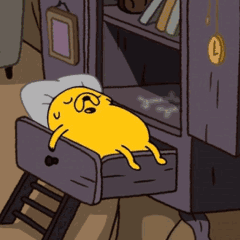

In [163]:
TestImage('jake_64_colors(240x240).bin','jake_64_colors(240x240)-ColorTable.txt',(240,240),6)

ColorTableLen: 4
LZW_Min_Code: 2
CodeTable len:  686


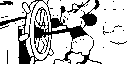

In [164]:
TestImage('steam_boat_monocrome(128x64).bin','steam_boat_monocrome(128x64)-ColorTable.txt',(128,64),2)